# Feature Set Experiment

Compare Numerai feature sets while keeping the model, target, training period, purge period, and validation period unchanged.

## Research Question

Does increasing the feature set from `small` (42 features) to `medium` (780 features) improve out-of-sample Numerai CORR?

## Experimental Setup

- **Baseline model:** LightGBM Regressor
- **Target:** Default Numerai target (`target_ender_60`)
- **Training eras:** `0001–0558`
- **Purged eras:** `0559–0574`
- **Validation eras:** `0575–1221`
- **Test eras:** `1222–1234` (untouched)

The only variable changed in this experiment is the feature set.

## Experiment Results

| Version | Features | Model | Mean CORR | CORR Std | Sharpe-like | Positive Eras |
|---|---|---|---:|---:|---:|---:|
| v0 | Small (42) | LightGBM | 0.017655 | 0.014758 | 1.196 | 87.48% |
| v1 | Medium (780) | LightGBM | 0.019724 | 0.015247 | 1.294 | 89.80% |

## 1. Load Feature Metadata

In [1]:
from pathlib import Path
import json

FEATURES_PATH = Path("../data/features.json")

with open(FEATURES_PATH, "r", encoding="utf-8") as f:
    feature_metadata = json.load(f)

small_features = feature_metadata["feature_sets"]["small"]
medium_features = feature_metadata["feature_sets"]["medium"]

print("Small features:", len(small_features))
print("Medium features:", len(medium_features))

Small features: 42
Medium features: 780


## 2. Estimate Medium Feature Data Size

In [2]:
import pyarrow.parquet as pq

TRAIN_PATH = Path("../data/train.parquet")
VALIDATION_PATH = Path("../data/validation.parquet")

train_file = pq.ParquetFile(TRAIN_PATH)
validation_file = pq.ParquetFile(VALIDATION_PATH)

train_rows = train_file.metadata.num_rows
validation_rows = validation_file.metadata.num_rows

print("Train rows:", train_rows)
print("Validation rows:", validation_rows)

print("Train medium cells:", train_rows * len(medium_features))
print("Validation medium cells:", validation_rows * len(medium_features))

Train rows: 2746268
Validation rows: 4128060
Train medium cells: 2142089040
Validation medium cells: 3219886800


## 3. Inspect Feature Data Types

In [3]:
example_feature = medium_features[0]

train_feature_type = train_file.schema_arrow.field(example_feature).type
#schema_arrow:数据觉狗说明，找到某一个feature，看他的type
validation_feature_type = validation_file.schema_arrow.field(example_feature).type

print("Example feature:", example_feature)
print("Train feature type:", train_feature_type)
print("Validation feature type:", validation_feature_type)

print("Era type:", train_file.schema_arrow.field("era").type)
print("Target type:", train_file.schema_arrow.field("target").type)

Example feature: feature_able_deprived_nona
Train feature type: int8
Validation feature type: int8
Era type: string
Target type: float


## 4. Load Medium Training Data

In [4]:
import pandas as pd

train_cols = ["era", "target"] + medium_features

train_medium = pd.read_parquet(
    TRAIN_PATH,
    columns=train_cols,
)

print("Shape:", train_medium.shape)

memory_gb = train_medium.memory_usage(deep=True).sum() / 1024**3
print(f"Memory usage: {memory_gb:.2f} GB")

print(train_medium.dtypes.value_counts())

Shape: (2746268, 782)
Memory usage: 2.10 GB
int8       780
str          1
float32      1
Name: count, dtype: int64


## 5. Apply 16-Era Purge

In [5]:
PURGE_ERAS = 16

validation_start_era = 575
train_end_era = validation_start_era - PURGE_ERAS - 1

train_medium_purged = train_medium[
    train_medium["era"].astype(int) <= train_end_era
].copy()
# 把era换成int，取era<=558的行

print("Original train rows:", len(train_medium))
print("Purged train rows:", len(train_medium_purged))
print("Training eras:", train_medium_purged["era"].nunique())
print("Last training era:", train_medium_purged["era"].max())

Original train rows: 2746268
Purged train rows: 2657277
Training eras: 558
Last training era: 0558


## 6. Load Medium Validation Data

In [6]:
validation_cols = ["era", "data_type", "target"] + medium_features

validation_medium = pd.read_parquet(
    VALIDATION_PATH,
    columns=validation_cols,
)

validation_medium = validation_medium[
    validation_medium["data_type"] == "validation"
].copy()

print("Shape:", validation_medium.shape)
print("Validation eras:", validation_medium["era"].nunique())
print("First validation era:", validation_medium["era"].min())
print("Last validation era:", validation_medium["era"].max())

memory_gb = validation_medium.memory_usage(deep=True).sum() / 1024**3
print(f"Memory usage: {memory_gb:.2f} GB")

Shape: (4036034, 783)
Validation eras: 647
First validation era: 0575
Last validation era: 1221
Memory usage: 3.15 GB


## 7. Prepare Training and Validation Sets

In [7]:
X_train = train_medium_purged[medium_features]
y_train = train_medium_purged["target"]

X_valid = validation_medium[medium_features]
y_valid = validation_medium["target"]

print("X_train:", X_train.shape)
print("y_train:", y_train.shape)
print("X_valid:", X_valid.shape)
print("y_valid:", y_valid.shape)

X_train: (2657277, 780)
y_train: (2657277,)
X_valid: (4036034, 780)
y_valid: (4036034,)


In [8]:
import gc

del train_medium
del validation_medium

gc.collect()

print("Unused DataFrames removed.")

Unused DataFrames removed.


## 8. Train Medium Feature Model

In [9]:
from lightgbm import LGBMRegressor

medium_model = LGBMRegressor(
    n_estimators=300,
    learning_rate=0.05,
    num_leaves=31,
    random_state=42,
    n_jobs=-1,
)

medium_model.fit(
    X_train,
    y_train,
)

print("Medium feature model training completed.")

[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 5.303616 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 3900
[LightGBM] [Info] Number of data points in the train set: 2657277, number of used features: 780
[LightGBM] [Info] Start training from score 0.499948
Medium feature model training completed.


## 9. Generate Validation Predictions

In [10]:
valid_predictions = medium_model.predict(X_valid)

print("Number of predictions:", len(valid_predictions))
print("Prediction min:", valid_predictions.min())
print("Prediction max:", valid_predictions.max())
print("Prediction mean:", valid_predictions.mean())

Number of predictions: 4036034
Prediction min: 0.4226958544681098
Prediction max: 0.5816817769460751
Prediction mean: 0.49990200495417864


## 10. Evaluate Numerai CORR

In [11]:
from scipy import stats
import numpy as np

def numerai_corr(preds, target): #CORR
    ranked_preds = (preds.rank(method="average") - 0.5) / preds.count()
    gauss_preds = stats.norm.ppf(ranked_preds)

    centered_target = target - target.mean()

    preds_p15 = np.sign(gauss_preds) * np.abs(gauss_preds) ** 1.5
    target_p15 = np.sign(centered_target) * np.abs(centered_target) ** 1.5

    return np.corrcoef(preds_p15, target_p15)[0, 1]

In [12]:
validation_meta = pd.read_parquet(
    VALIDATION_PATH,
    columns=["era", "data_type"],
)

validation_eras = validation_meta[
    validation_meta["data_type"] == "validation"
]["era"].reset_index(drop=True)

validation_results = pd.DataFrame({
    "era": validation_eras,
    "target": y_valid.reset_index(drop=True),
    "prediction": valid_predictions,
})

print(validation_results.shape)
print(validation_results.head())

(4036034, 3)
    era  target  prediction
0  0575    0.50    0.501787
1  0575    0.25    0.490664
2  0575    0.50    0.493135
3  0575    0.00    0.490884
4  0575    0.50    0.507446


In [13]:
numerai_era_corr = validation_results.groupby("era").apply(
    lambda x: numerai_corr(x["prediction"], x["target"])
)

print(numerai_era_corr.describe())

count    647.000000
mean       0.019724
std        0.015247
min       -0.029142
25%        0.009689
50%        0.019823
75%        0.029537
max        0.066645
dtype: float64


## 11. Performance Summary

In [14]:
mean_corr = numerai_era_corr.mean()
std_corr = numerai_era_corr.std()

corr_sharpe = mean_corr / std_corr
positive_era_rate = (numerai_era_corr > 0).mean()

print(f"Mean CORR: {mean_corr:.6f}")
print(f"CORR Std: {std_corr:.6f}")
print(f"CORR Sharpe-like: {corr_sharpe:.3f}")
print(f"Positive Era Rate: {positive_era_rate:.2%}")

Mean CORR: 0.019724
CORR Std: 0.015247
CORR Sharpe-like: 1.294
Positive Era Rate: 89.80%


## 12. Rolling CORR Analysis

<Axes: title={'center': '20-Era Rolling Mean Numerai CORR — Medium Features'}, xlabel='Era', ylabel='Rolling Mean CORR'>

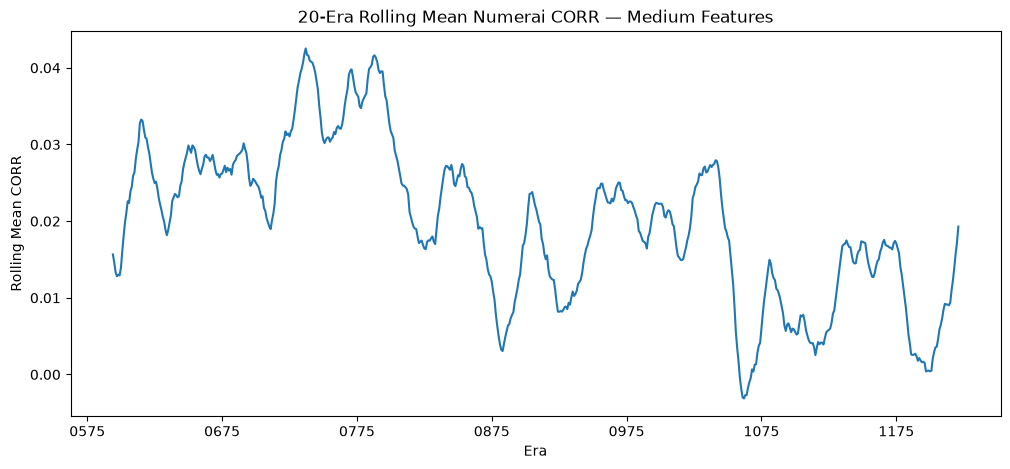

In [15]:
rolling_corr = numerai_era_corr.rolling(20).mean()

rolling_corr.plot(
    figsize=(12, 5),
    title="20-Era Rolling Mean Numerai CORR — Medium Features",
    xlabel="Era",
    ylabel="Rolling Mean CORR",
)

## 13. Conclusion

Increasing the feature set from `small` (42 features) to `medium` (780 features) improved the out-of-sample performance of the baseline LightGBM model while keeping the model parameters, target, training period, purge period, and validation period unchanged.

### Results

- **Mean CORR:** 0.017655 → 0.019724 (**+11.7%**)
- **CORR Sharpe-like ratio:** 1.196 → 1.294
- **Positive era rate:** 87.48% → 89.80%
- **Median CORR:** 0.018351 → 0.019823

The medium feature set therefore provides additional predictive information beyond the small feature set.

However, performance is not uniform across time. The 20-era rolling CORR shows clear variation in signal strength, including several weaker periods, and the worst individual era CORR decreased from -0.018555 to -0.029142.

### Decision

The medium-feature LightGBM model (`v1`) becomes the new working benchmark for subsequent experiments.

Future experiments should focus not only on increasing average CORR, but also on improving stability across eras.